# Teen Mental Health Data — Comprehensive Medical Statistical Analysis

**Skills used:** medical-stat-three-line-table, medical-stat-stat-plot, medical-stat-anova, medical-stat-nonparametric, medical-stat-chisq, medical-stat-correlation, medical-stat-logistic-reg, medical-stat-roc, medical-stat-pca, medical-stat-pca-vis

**Dataset:** `Teen_Mental_Health.csv` (n = 1,200)

**Outcomes:** digital_wellbeing_flag (At Risk / Moderate / Healthy), depression_label (0/1)

**Variables:** age, gender, daily_social_media_hours, platform_usage, sleep_hours, screen_time_before_sleep, academic_performance, physical_activity, social_interaction_level, stress_level, anxiety_level, addiction_level, mental_health_risk_score, sleep_quality

In [1]:
.libPaths(c("/Users/leigao/Library/R/arm64/4.2/library", "/Library/Frameworks/R.framework/Versions/4.2-arm64/Resources/library"))

# ============================================================
# SECTION 0: Setup and package loading
# ============================================================
suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(broom)
  library(pROC)
  library(corrplot)
  library(MASS)
  library(patchwork)
  library(scales)
  library(cluster)
  library(survival)
})

data_dir <- "/Users/leigao/Documents/R-Medical-Statistics-Skills/example/teen-mental-health/data"
out_dir <- "/Users/leigao/Documents/R-Medical-Statistics-Skills/example/teen-mental-health/data/analysis"
fig_dir <- file.path(out_dir, "figures")
dir.create(fig_dir, recursive = TRUE, showWarnings = FALSE)

cat("Packages loaded successfully.\n")

Packages loaded successfully.


In [2]:
# ============================================================
# SECTION 1: Data loading and preprocessing
# ============================================================
raw <- read.csv(file.path(data_dir, "Teen_Mental_Health.csv"), stringsAsFactors = FALSE)

# Fix BOM in first column name
colnames(raw)[1] <- "age"

cat(sprintf("Dataset: %d rows x %d columns\n", nrow(raw), ncol(raw)))
cat("Column names:\n")
print(colnames(raw))
str(raw)

# Clean and recode
df <- raw

# Factor conversions
df$gender <- factor(df$gender, levels = c("male", "female"), labels = c("Male", "Female"))
df$platform_usage <- factor(df$platform_usage, levels = c("Facebook", "Instagram", "TikTok", "YouTube", "All Platforms"))
df$social_interaction_level <- factor(df$social_interaction_level, levels = c("low", "medium", "high"), ordered = TRUE)
df$sleep_quality <- factor(df$sleep_quality, levels = c("Poor", "Fair", "Good"), ordered = TRUE)
df$digital_wellbeing_flag <- factor(df$digital_wellbeing_flag, levels = c("Healthy", "Moderate", "At Risk"), ordered = TRUE)
df$depression_label <- factor(df$depression_label, levels = c(0, 1), labels = c("No", "Yes"))

cat("\nData preprocessing complete.\n")
cat("\n--- Outcome distributions ---\n")
cat("digital_wellbeing_flag:\n"); print(table(df$digital_wellbeing_flag))
cat("depression_label:\n"); print(table(df$depression_label))
cat("\n--- Categorical predictors ---\n")
cat("gender:\n"); print(table(df$gender))
cat("platform_usage:\n"); print(table(df$platform_usage))

Dataset: 1200 rows x 16 columns


Column names:


 [1] "age"                      "gender"                  
 [3] "daily_social_media_hours" "platform_usage"          
 [5] "sleep_hours"              "screen_time_before_sleep"
 [7] "academic_performance"     "physical_activity"       
 [9] "social_interaction_level" "stress_level"            
[11] "anxiety_level"            "addiction_level"         
[13] "depression_label"         "mental_health_risk_score"
[15] "sleep_quality"            "digital_wellbeing_flag"  


'data.frame':	1200 obs. of  16 variables:
 $ age                     : int  14 19 17 15 15 19 18 16 19 15 ...
 $ gender                  : chr  "male" "female" "female" "male" ...
 $ daily_social_media_hours: num  7.9 1.9 1.3 7.4 4.7 7.4 2.5 4 3.3 1.9 ...
 $ platform_usage          : chr  "Facebook" "TikTok" "Instagram" "YouTube" ...
 $ sleep_hours             : num  7.4 8 7.6 6.9 4.9 4.4 6.4 4.2 5 4.9 ...
 $ screen_time_before_sleep: num  2.9 2.9 0.5 1.6 3 2.4 2.4 0.5 2.1 1.5 ...
 $ academic_performance    : num  3.01 3.22 3.92 3.48 2.37 2.63 2.63 2.4 2.04 3.77 ...
 $ physical_activity       : num  1.5 0.8 0 0.8 1.4 0.6 0.7 1.3 0.9 1.1 ...
 $ social_interaction_level: chr  "low" "high" "high" "medium" ...
 $ stress_level            : int  2 8 2 1 3 3 2 6 1 1 ...
 $ anxiety_level           : int  2 1 4 7 5 5 2 10 10 1 ...
 $ addiction_level         : int  1 10 2 9 2 7 5 5 9 4 ...
 $ depression_label        : int  0 0 0 0 0 0 0 0 0 0 ...
 $ mental_health_risk_score: int  5 19 8 17 10 15


Data preprocessing complete.


...


--- Categorical predictors ---


gender:



  Male Female 
   615    585 


platform_usage:



     Facebook     Instagram        TikTok       YouTube All Platforms 
          171           240           240           158           391 


In [3]:
# ============================================================
# SECTION 2: Descriptive statistics (Table 1 by wellbeing)
# Skill: medical-stat-three-line-table
# ============================================================

cat("\n========== 2.1 Overall Summary ==========\n")
summary(df)

cat("\n========== 2.2 Descriptive by digital_wellbeing_flag ==========\n")

# Numeric variables
num_vars <- c("age", "daily_social_media_hours", "sleep_hours", "screen_time_before_sleep",
              "academic_performance", "physical_activity", "stress_level", "anxiety_level",
              "addiction_level", "mental_health_risk_score")

for (var in num_vars) {
  cat(sprintf("\n--- %s ---\n", var))
  summ <- df %>%
    group_by(digital_wellbeing_flag) %>%
    summarise(
      Mean = mean(.data[[var]], na.rm = TRUE),
      SD = sd(.data[[var]], na.rm = TRUE),
      Median = median(.data[[var]], na.rm = TRUE)
    )
  print(as.data.frame(summ))
}

# Categorical variables
cat_vars <- c("gender", "platform_usage", "social_interaction_level", "sleep_quality", "depression_label")
for (var in cat_vars) {
  cat(sprintf("\n--- %s ---\n", var))
  tbl <- table(df[[var]], df$digital_wellbeing_flag)
  print(tbl)
  print(round(prop.table(tbl, 2) * 100, 1))
}


========== 2.1 Overall Summary ==========


      age           gender    daily_social_media_hours       platform_usage
 Min.   :13.00   Male  :615   Min.   :1.000            Facebook     :171   
 1st Qu.:14.00   Female:585   1st Qu.:2.800            Instagram    :240   
 Median :16.00                Median :4.500            TikTok       :240   
 Mean   :15.93                Mean   :4.537            YouTube      :158   
 3rd Qu.:18.00                3rd Qu.:6.300            All Platforms:391   
 Max.   :19.00                Max.   :8.000                                
  sleep_hours    screen_time_before_sleep academic_performance
 Min.   :4.000   Min.   :0.50             Min.   :2.00        
 1st Qu.:5.200   1st Qu.:1.10             1st Qu.:2.50        
 Median :6.500   Median :1.80             Median :2.99        
 Mean   :6.449   Mean   :1.74             Mean   :2.99        
 3rd Qu.:7.600   3rd Qu.:2.40             3rd Qu.:3.48        
 Max.   :9.000   Max.   :3.00             Max.   :4.00        
 physical_activity social_i


========== 2.2 Descriptive by digital_wellbeing_flag ==========



--- age ---
  digital_wellbeing_flag     Mean       SD Median
1                Healthy 15.67320 2.052843     16
2               Moderate 15.98654 2.006682     16
3                At Risk 16.15894 1.996973     16

--- daily_social_media_hours ---
  digital_wellbeing_flag     Mean        SD Median
1                Healthy 2.550980 0.8632092    2.6
2               Moderate 4.836339 1.8007332    5.0
3                At Risk 7.086093 0.5830997    7.2

--- sleep_hours ---
  digital_wellbeing_flag     Mean       SD Median
1                Healthy 6.471242 1.510495    6.5
2               Moderate 6.455047 1.406568    6.5
3                At Risk 6.377483 1.484730    6.4

--- screen_time_before_sleep ---
  digital_wellbeing_flag     Mean        SD Median
1                Healthy 1.217320 0.4184209    1.2
2               Moderate 1.809825 0.7181872    1.9
3                At Risk 2.458278 0.3116318    2.4

--- academic_performance ---
  digital_wellbeing_flag     Mean        SD Median
1        


--- gender ---
        
         Healthy Moderate At Risk
  Male       155      382      78
  Female     151      361      73
        
         Healthy Moderate At Risk
  Male      50.7     51.4    51.7
  Female    49.3     48.6    48.3

--- platform_usage ---
               
                Healthy Moderate At Risk
  Facebook           45      101      25
  Instagram          70      142      28
  TikTok             61      154      25
  YouTube            37      102      19
  All Platforms      93      244      54
               
                Healthy Moderate At Risk
  Facebook         14.7     13.6    16.6
  Instagram        22.9     19.1    18.5
  TikTok           19.9     20.7    16.6
  YouTube          12.1     13.7    12.6
  All Platforms    30.4     32.8    35.8

--- social_interaction_level ---
        
         Healthy Moderate At Risk
  low         96      265      54
  medium     109      263      44
  high       101      215      53
        
         Healthy Moderate 

In [4]:
# 2.3 Export Table 1 to CSV
cat("\n========== 2.3 Exporting Table 1 ==========\n")

table1 <- data.frame(Variable = character(), Healthy = character(), 
                     Moderate = character(), At_Risk = character(), stringsAsFactors = FALSE)

# N
table1 <- rbind(table1, data.frame(
  Variable = "N", Healthy = as.character(sum(df$digital_wellbeing_flag == "Healthy")),
  Moderate = as.character(sum(df$digital_wellbeing_flag == "Moderate")),
  At_Risk = as.character(sum(df$digital_wellbeing_flag == "At Risk"))))

# Numeric variables: mean ± SD
for (var in num_vars) {
  means <- tapply(df[[var]], df$digital_wellbeing_flag, mean, na.rm = TRUE)
  sds <- tapply(df[[var]], df$digital_wellbeing_flag, sd, na.rm = TRUE)
  table1 <- rbind(table1, data.frame(
    Variable = sprintf("%s (mean ± SD)", var),
    Healthy = sprintf("%.2f ± %.2f", means["Healthy"], sds["Healthy"]),
    Moderate = sprintf("%.2f ± %.2f", means["Moderate"], sds["Moderate"]),
    At_Risk = sprintf("%.2f ± %.2f", means["At Risk"], sds["At Risk"])))
}

# Categorical: show % of each level
for (var in cat_vars) {
  tbl <- table(df[[var]], df$digital_wellbeing_flag)
  pct <- prop.table(tbl, 2) * 100
  for (lvl in rownames(tbl)) {
    table1 <- rbind(table1, data.frame(
      Variable = sprintf("%s = %s", var, lvl),
      Healthy = sprintf("%d (%.1f%%)", tbl[lvl, "Healthy"], pct[lvl, "Healthy"]),
      Moderate = sprintf("%d (%.1f%%)", tbl[lvl, "Moderate"], pct[lvl, "Moderate"]),
      At_Risk = sprintf("%d (%.1f%%)", tbl[lvl, "At Risk"], pct[lvl, "At Risk"])))
  }
}

print(table1, row.names = FALSE)
write.csv(table1, file.path(out_dir, "table1_by_wellbeing.csv"), row.names = FALSE)
cat("\nTable 1 saved.\n")


========== 2.3 Exporting Table 1 ==========


                              Variable       Healthy      Moderate
                                     N           306           743
                      age (mean ± SD) 15.67 ± 2.05 15.99 ± 2.01
 daily_social_media_hours (mean ± SD)  2.55 ± 0.86  4.84 ± 1.80
              sleep_hours (mean ± SD)  6.47 ± 1.51  6.46 ± 1.41
 screen_time_before_sleep (mean ± SD)  1.22 ± 0.42  1.81 ± 0.72
     academic_performance (mean ± SD)  2.99 ± 0.58  2.98 ± 0.58
        physical_activity (mean ± SD)  1.01 ± 0.59  1.00 ± 0.59
             stress_level (mean ± SD)  5.48 ± 2.88  5.37 ± 2.90
            anxiety_level (mean ± SD)  5.62 ± 2.84  5.67 ± 2.85
          addiction_level (mean ± SD)  5.44 ± 2.83  5.60 ± 2.83
 mental_health_risk_score (mean ± SD) 16.54 ± 5.30 16.64 ± 4.96
                         gender = Male   155 (50.7%)   382 (51.4%)
                       gender = Female   151 (49.3%)   361 (48.6%)
             platform_usage = Facebook    45 (14.7%)   101 (13.6%)
            platform_usag


Table 1 saved.


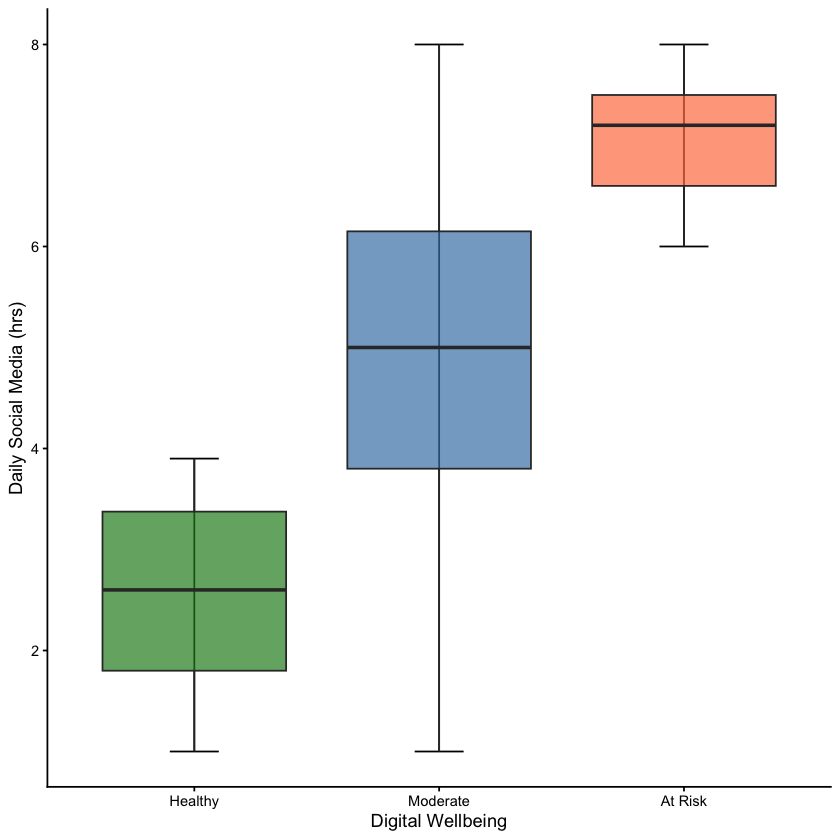

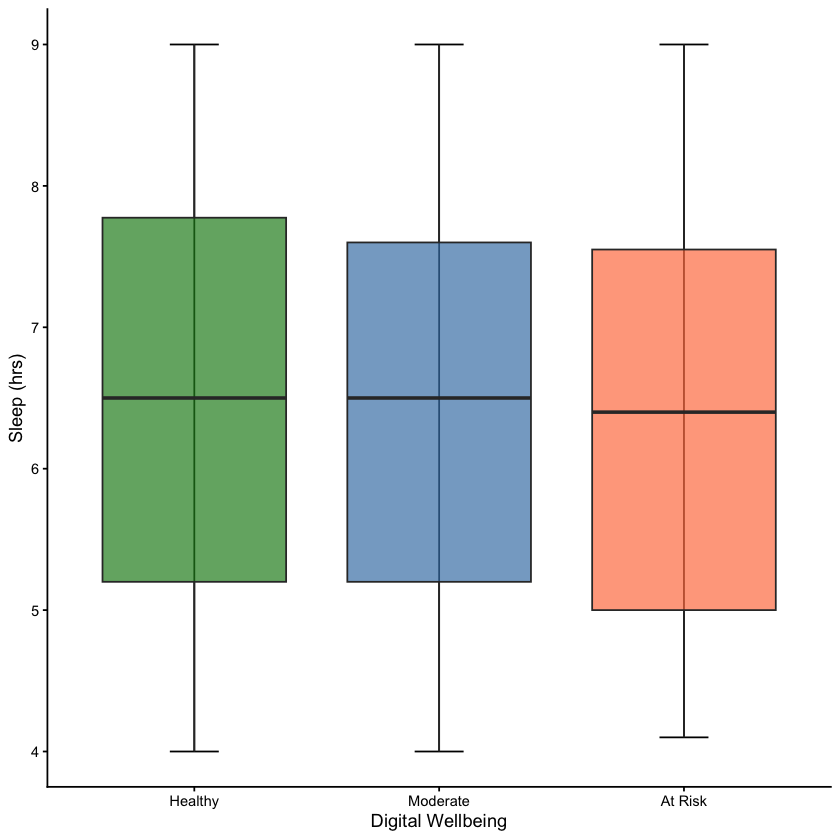

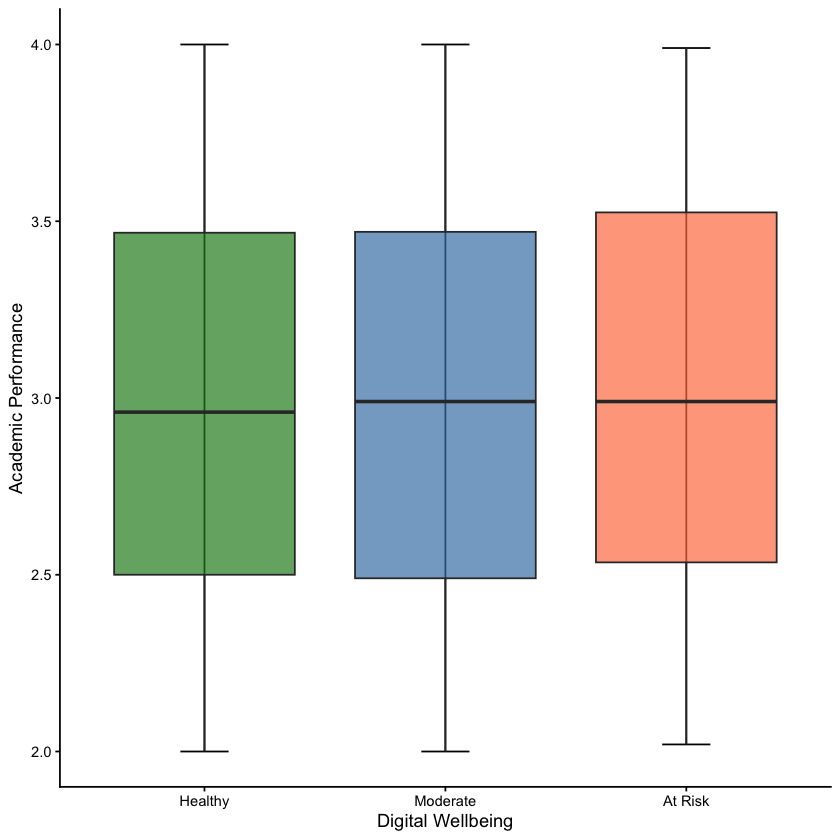

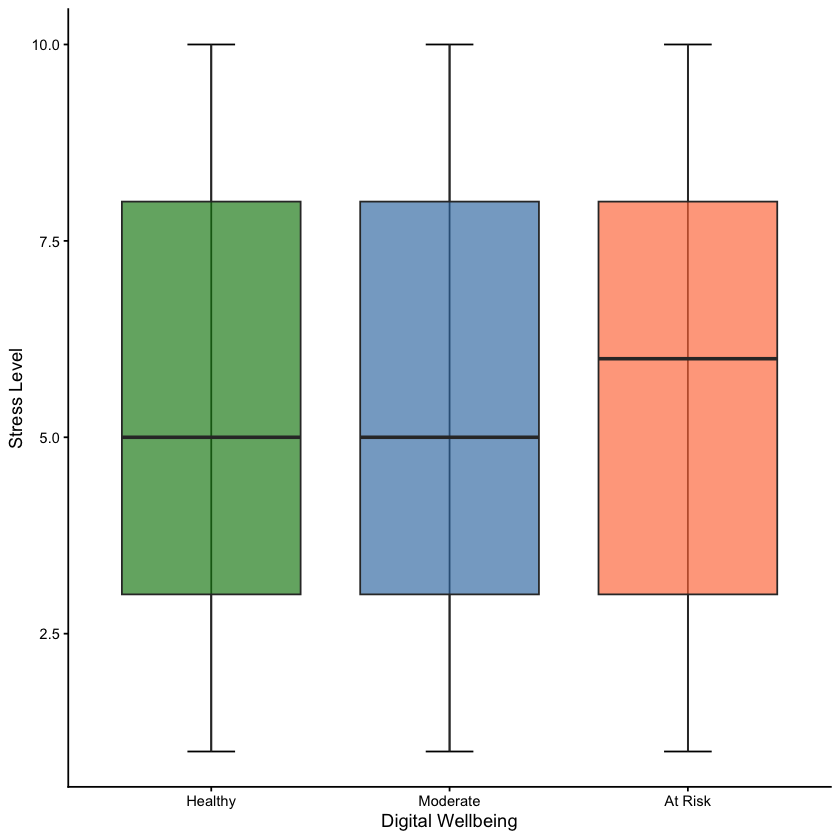

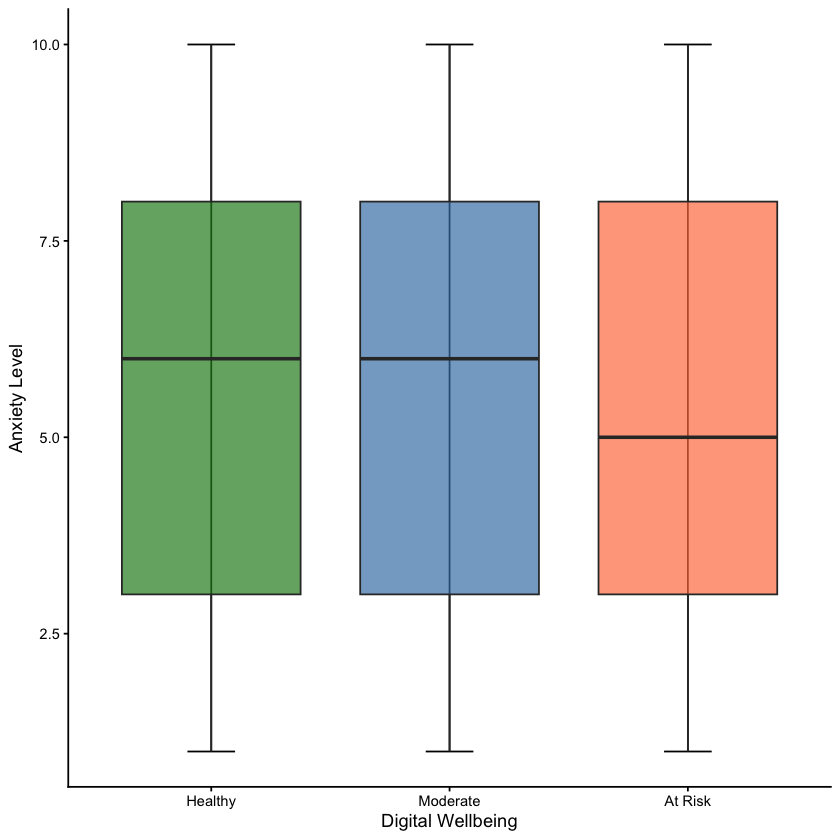

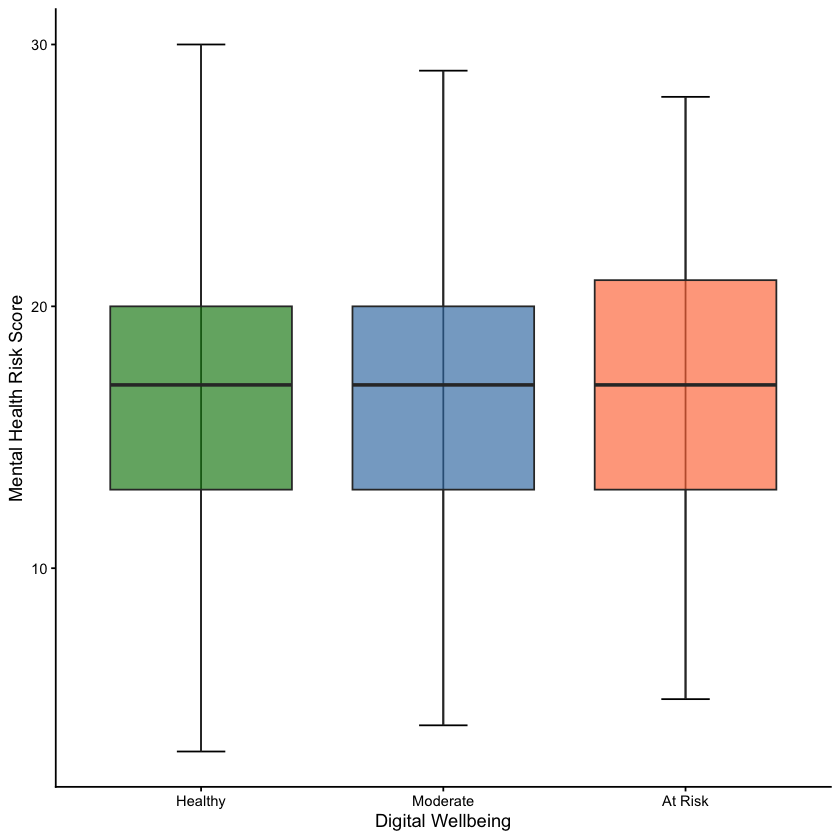

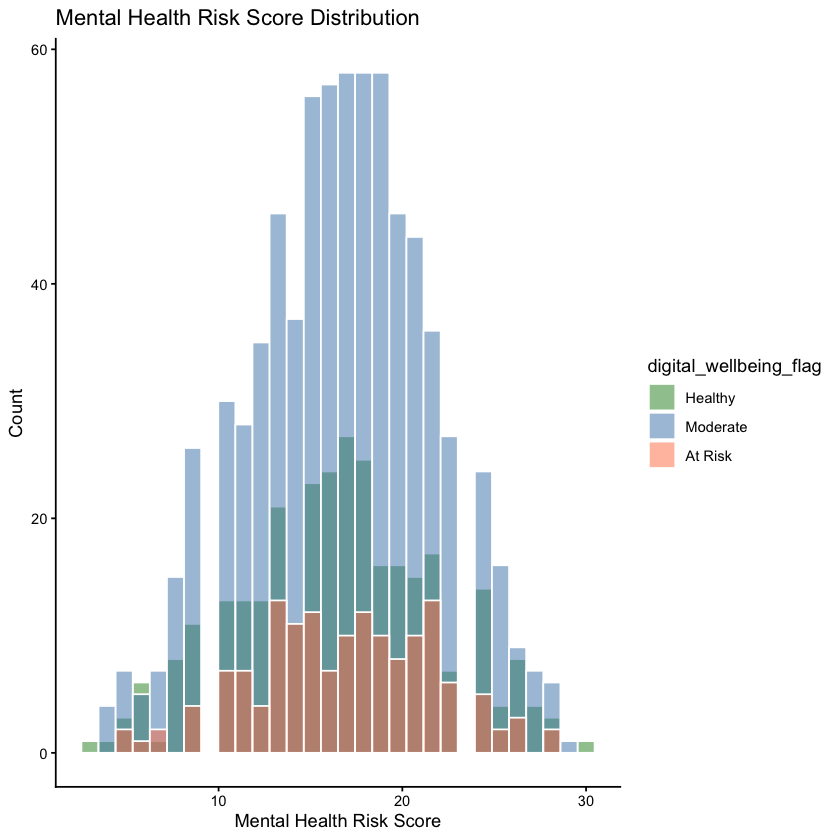

In [5]:
# ============================================================
# SECTION 3: Statistical plots
# Skill: medical-stat-stat-plot
# ============================================================

# 3.1 Boxplots: key variables by wellbeing
num_plot_vars <- c("daily_social_media_hours", "sleep_hours", "academic_performance", 
                    "stress_level", "anxiety_level", "mental_health_risk_score")
plot_labels <- c("Daily Social Media (hrs)", "Sleep (hrs)", "Academic Performance",
                 "Stress Level", "Anxiety Level", "Mental Health Risk Score")

for (i in 1:length(num_plot_vars)) {
  p <- ggplot(df, aes(digital_wellbeing_flag, .data[[num_plot_vars[i]]])) +
    stat_boxplot(geom = "errorbar", width = 0.2) +
    geom_boxplot(aes(fill = digital_wellbeing_flag), alpha = 0.7) +
    scale_fill_manual(values = c("forestgreen", "steelblue", "coral")) +
    labs(x = "Digital Wellbeing", y = plot_labels[i]) +
    theme_classic() + theme(legend.position = "none")
  ggsave(file.path(fig_dir, paste0("boxplot_", num_plot_vars[i], ".pdf")), p, width = 6, height = 4.5)
  print(p)
}

# 3.2 Histogram: mental_health_risk_score
p_hist <- ggplot(df, aes(mental_health_risk_score, fill = digital_wellbeing_flag)) +
  geom_histogram(alpha = 0.5, bins = 30, position = "identity", color = "white") +
  scale_fill_manual(values = c("forestgreen", "steelblue", "coral")) +
  labs(x = "Mental Health Risk Score", y = "Count", title = "Mental Health Risk Score Distribution") +
  theme_classic()
ggsave(file.path(fig_dir, "hist_risk_score.pdf"), p_hist, width = 7, height = 5)
print(p_hist)

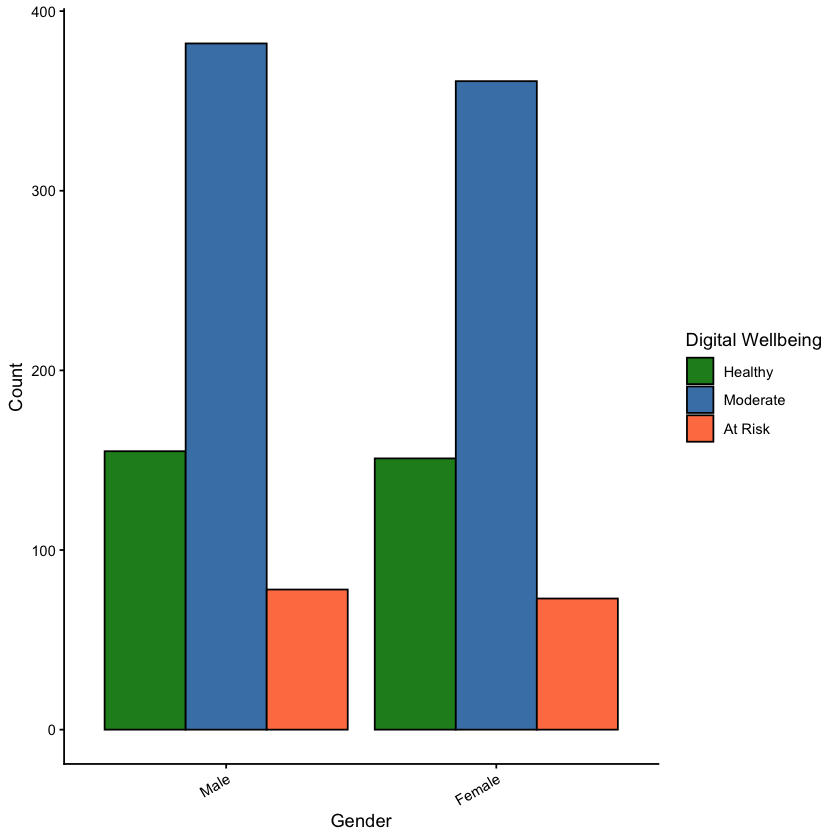

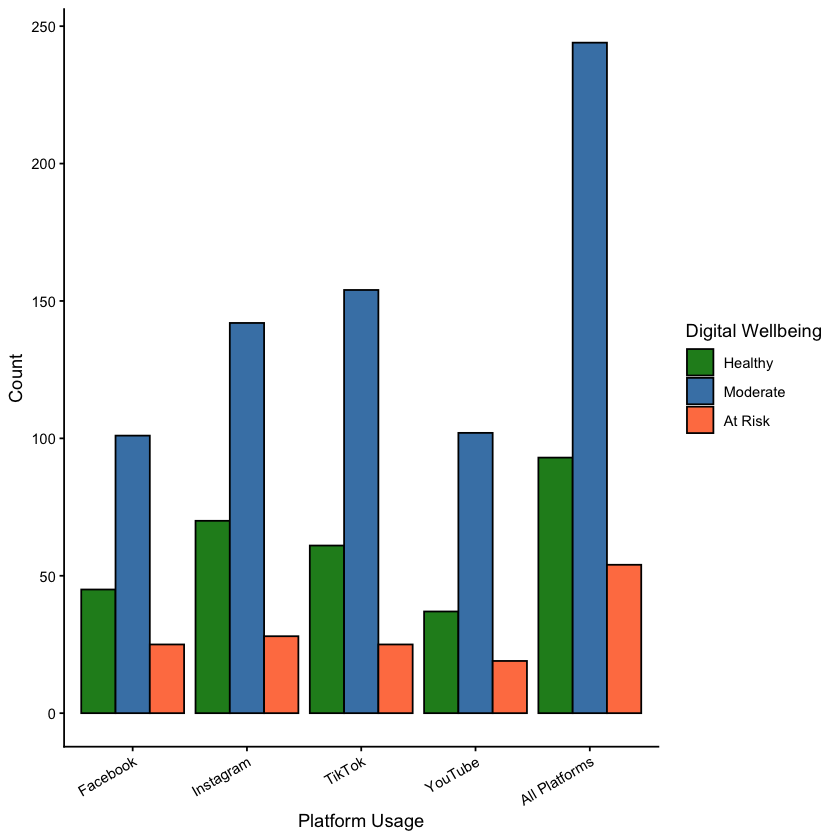

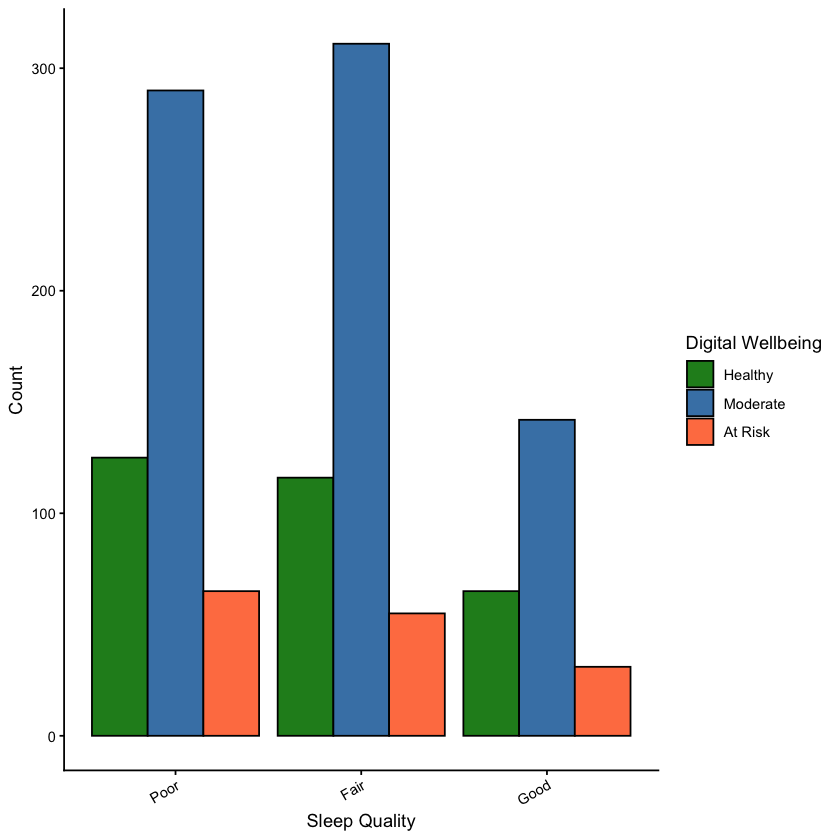

`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


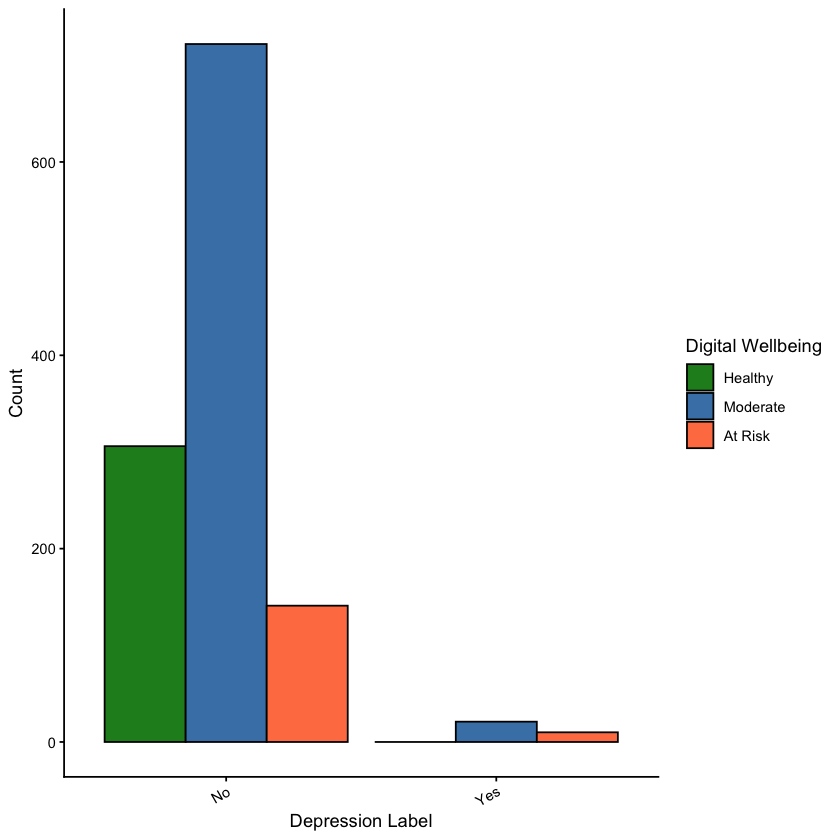

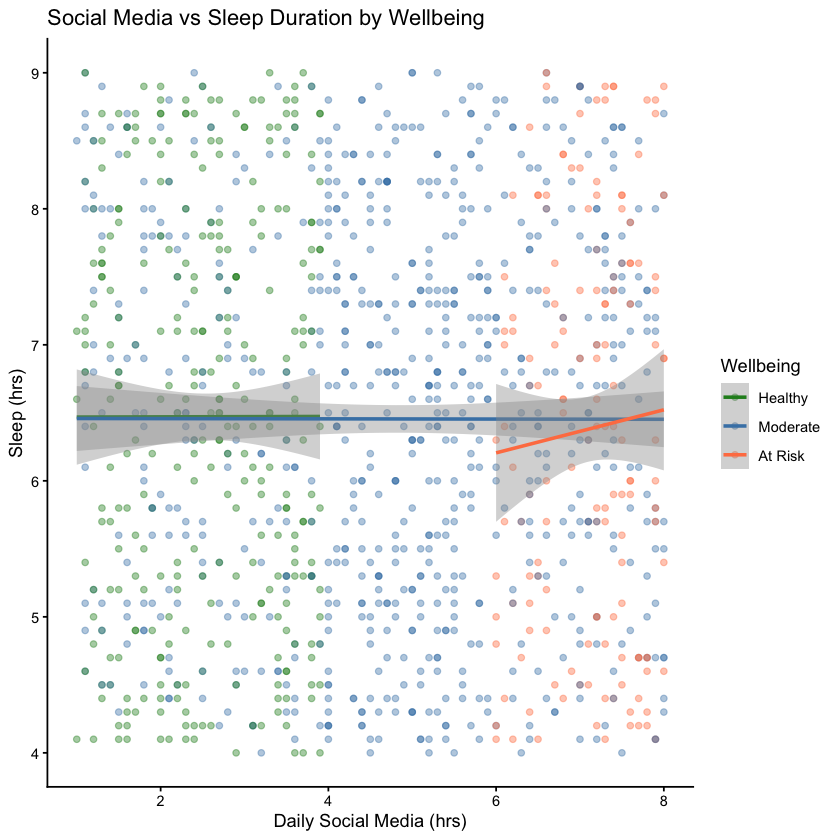

In [6]:
# 3.3 Bar charts: categorical variables by wellbeing
cat_vars_plot <- c("gender", "platform_usage", "sleep_quality", "depression_label")
cat_labels <- c("Gender", "Platform Usage", "Sleep Quality", "Depression Label")

for (i in 1:length(cat_vars_plot)) {
  plot_df <- as.data.frame(table(df[[cat_vars_plot[i]]], df$digital_wellbeing_flag))
  colnames(plot_df) <- c("Category", "Wellbeing", "Count")
  
  p <- ggplot(plot_df, aes(Category, Count, fill = Wellbeing)) +
    geom_bar(stat = "identity", position = "dodge", color = "black") +
    scale_fill_manual(values = c("forestgreen", "steelblue", "coral")) +
    labs(x = cat_labels[i], y = "Count", fill = "Digital Wellbeing") +
    theme_classic() + theme(axis.text.x = element_text(angle = 30, hjust = 1))
  ggsave(file.path(fig_dir, paste0("bar_", cat_vars_plot[i], ".pdf")), p, width = 7, height = 5)
  print(p)
}

# 3.4 Scatter: social_media_hours vs sleep_hours
p_scatter <- ggplot(df, aes(daily_social_media_hours, sleep_hours, color = digital_wellbeing_flag)) +
  geom_point(alpha = 0.4, size = 1.5) +
  geom_smooth(method = "lm", se = TRUE) +
  scale_color_manual(values = c("forestgreen", "steelblue", "coral")) +
  labs(x = "Daily Social Media (hrs)", y = "Sleep (hrs)", color = "Wellbeing",
       title = "Social Media vs Sleep Duration by Wellbeing") +
  theme_classic()
ggsave(file.path(fig_dir, "scatter_social_sleep.pdf"), p_scatter, width = 8, height = 5)
print(p_scatter)

In [7]:
# ============================================================
# SECTION 4: ANOVA / Kruskal-Wallis — Compare numeric vars by wellbeing
# Skills: medical-stat-anova, medical-stat-nonparametric
# ============================================================

cat("\n========== 4.1 Normality test (Shapiro-Wilk) per group ==========\n")
for (var in num_vars) {
  cat(sprintf("\n--- %s ---\n", var))
  for (grp in levels(df$digital_wellbeing_flag)) {
    vals <- df[[var]][df$digital_wellbeing_flag == grp]
    if (length(vals) > 3 && length(vals) < 5000) {
      sw <- shapiro.test(vals)
      cat(sprintf("  %s: W=%.4f p=%.4f\n", grp, sw$statistic, sw$p.value))
    }
  }
}

cat("\n========== 4.2 ANOVA / Kruskal-Wallis ==========\n")
test_results <- data.frame(Variable = character(), Test = character(), 
                           Statistic = character(), p_value = numeric(), stringsAsFactors = FALSE)

for (var in num_vars) {
  # Kruskal-Wallis (non-parametric, safer default)
  kw <- kruskal.test(df[[var]] ~ df$digital_wellbeing_flag)
  
  # Also ANOVA for comparison
  aov_res <- aov(df[[var]] ~ df$digital_wellbeing_flag)
  aov_p <- summary(aov_res)[[1]]$"Pr(>F)"[1]
  
  test_results <- rbind(test_results, data.frame(
    Variable = var, Test = "Kruskal-Wallis",
    Statistic = sprintf("H=%.2f", kw$statistic),
    p_value = kw$p.value))
  
  cat(sprintf("%-30s KW H=%-8.2f p=%s   ANOVA F p=%s\n",
              var, kw$statistic,
              ifelse(kw$p.value < 0.001, "<0.001", sprintf("%.6f", kw$p.value)),
              ifelse(aov_p < 0.001, "<0.001", sprintf("%.6f", aov_p))))
}

write.csv(test_results, file.path(out_dir, "anova_kruskal_results.csv"), row.names = FALSE)


========== 4.1 Normality test (Shapiro-Wilk) per group ==========



--- age ---
  Healthy: W=0.9032 p=0.0000
  Moderate: W=0.9170 p=0.0000
  At Risk: W=0.9181 p=0.0000

--- daily_social_media_hours ---
  Healthy: W=0.9461 p=0.0000
  Moderate: W=0.9704 p=0.0000
  At Risk: W=0.9497 p=0.0000

--- sleep_hours ---
  Healthy: W=0.9440 p=0.0000
  Moderate: W=0.9586 p=0.0000
  At Risk: W=0.9453 p=0.0000

--- screen_time_before_sleep ---
  Healthy: W=0.9500 p=0.0000
  Moderate: W=0.9536 p=0.0000
  At Risk: W=0.9256 p=0.0000

--- academic_performance ---
  Healthy: W=0.9537 p=0.0000
  Moderate: W=0.9544 p=0.0000
  At Risk: W=0.9451 p=0.0000

--- physical_activity ---
  Healthy: W=0.9473 p=0.0000
  Moderate: W=0.9507 p=0.0000
  At Risk: W=0.9631 p=0.0005

--- stress_level ---
  Healthy: W=0.9358 p=0.0000
  Moderate: W=0.9322 p=0.0000
  At Risk: W=0.9244 p=0.0000

--- anxiety_level ---
  Healthy: W=0.9377 p=0.0000
  Moderate: W=0.9361 p=0.0000
  At Risk: W=0.9230 p=0.0000

--- addiction_level ---
  Healthy: W=0.9380 p=0.0000
  Moderate: W=0.9375 p=0.0000
  At Ris


========== 4.2 ANOVA / Kruskal-Wallis ==========


age                            KW H=7.47     p=0.023825   ANOVA F p=0.023960
daily_social_media_hours       KW H=549.55   p=<0.001   ANOVA F p=<0.001
sleep_hours                    KW H=0.43     p=0.805949   ANOVA F p=0.796093
screen_time_before_sleep       KW H=323.91   p=<0.001   ANOVA F p=<0.001
academic_performance           KW H=1.02     p=0.599769   ANOVA F p=0.600307
physical_activity              KW H=3.30     p=0.192443   ANOVA F p=0.183466
stress_level                   KW H=2.05     p=0.359184   ANOVA F p=0.361186
anxiety_level                  KW H=0.36     p=0.833805   ANOVA F p=0.829499
addiction_level                KW H=0.83     p=0.658794   ANOVA F p=0.669262
mental_health_risk_score       KW H=0.51     p=0.773989   ANOVA F p=0.788375


In [8]:
# ============================================================
# 4.3 Pairwise comparisons (Dunn test for post-hoc)
# ============================================================
cat("\n========== 4.3 Pairwise Wilcoxon (Bonferroni corrected) ==========\n")

pairwise_results <- data.frame(Variable = character(), Comparison = character(),
                               p_value = numeric(), stringsAsFactors = FALSE)

for (var in num_vars) {
  pw <- pairwise.wilcox.test(df[[var]], df$digital_wellbeing_flag, p.adjust.method = "bonferroni")
  pmat <- as.data.frame(as.table(pw$p.value))
  pmat <- pmat[!is.na(pmat$Freq), ]
  for (j in 1:nrow(pmat)) {
    pairwise_results <- rbind(pairwise_results, data.frame(
      Variable = var, 
      Comparison = sprintf("%s vs %s", pmat$Var1[j], pmat$Var2[j]),
      p_value = pmat$Freq[j]))
  }
  cat(sprintf("\n--- %s ---\n", var))
  cat(sprintf("  %s vs %s: p=%s\n", pmat$Var1[1], pmat$Var2[1],
              ifelse(pmat$Freq[1] < 0.001, "<0.001", sprintf("%.4f", pmat$Freq[1]))))
}

write.csv(pairwise_results, file.path(out_dir, "pairwise_wilcoxon.csv"), row.names = FALSE)


========== 4.3 Pairwise Wilcoxon (Bonferroni corrected) ==========



--- age ---
  Moderate vs Healthy: p=0.0650

--- daily_social_media_hours ---
  Moderate vs Healthy: p=<0.001

--- sleep_hours ---
  Moderate vs Healthy: p=1.0000

--- screen_time_before_sleep ---
  Moderate vs Healthy: p=<0.001

--- academic_performance ---
  Moderate vs Healthy: p=1.0000

--- physical_activity ---
  Moderate vs Healthy: p=1.0000

--- stress_level ---
  Moderate vs Healthy: p=1.0000

--- anxiety_level ---
  Moderate vs Healthy: p=1.0000

--- addiction_level ---
  Moderate vs Healthy: p=1.0000

--- mental_health_risk_score ---
  Moderate vs Healthy: p=1.0000


In [9]:
# ============================================================
# SECTION 5: Chi-square tests — Categorical variables vs wellbeing
# Skill: medical-stat-chisq
# ============================================================

cat("\n========== 5. Chi-Square Tests ==========\n")

chisq_vars <- c("gender", "platform_usage", "sleep_quality", "depression_label", "social_interaction_level")
chisq_results <- data.frame(Variable = character(), Chi_Sq = numeric(), df = integer(),
                            p_value = numeric(), stringsAsFactors = FALSE)

for (var in chisq_vars) {
  tbl <- table(df[[var]], df$digital_wellbeing_flag)
  res <- chisq.test(tbl, correct = FALSE)
  
  chisq_results <- rbind(chisq_results, data.frame(
    Variable = var, Chi_Sq = res$statistic, df = res$parameter, p_value = res$p.value))
  
  cat(sprintf("%-30s χ² = %-8.2f df = %d  p = %s\n",
              var, res$statistic, res$parameter,
              ifelse(res$p.value < 0.001, "<0.001", sprintf("%.4f", res$p.value))))
}

# Bonferroni correction
chisq_results$p_adjusted <- p.adjust(chisq_results$p_value, method = "bonferroni")
cat("\n--- After Bonferroni correction ---\n")
for (i in 1:nrow(chisq_results)) {
  cat(sprintf("%-30s adjusted p = %s\n", chisq_results$Variable[i],
              ifelse(chisq_results$p_adjusted[i] < 0.001, "<0.001", 
                     sprintf("%.4f", chisq_results$p_adjusted[i]))))
}

write.csv(chisq_results, file.path(out_dir, "chisq_wellbeing_results.csv"), row.names = FALSE)


========== 5. Chi-Square Tests ==========


gender                         χ² = 0.06     df = 2  p = 0.9698
platform_usage                 χ² = 5.06     df = 8  p = 0.7508
sleep_quality                  χ² = 2.56     df = 4  p = 0.6336


Warning message in chisq.test(tbl, correct = FALSE):
“Chi-squared近似算法有可能不准”


depression_label               χ² = 18.08    df = 2  p = <0.001
social_interaction_level       χ² = 4.98     df = 4  p = 0.2893



--- After Bonferroni correction ---


gender                         adjusted p = 1.0000
platform_usage                 adjusted p = 1.0000
sleep_quality                  adjusted p = 1.0000
depression_label               adjusted p = <0.001
social_interaction_level       adjusted p = 1.0000



========== 6. Correlation Analysis ==========


pdf 
  2


--- Top correlations with mental_health_risk_score ---


anxiety_level                  rho =  0.5881
stress_level                   rho =  0.5746
addiction_level                rho =  0.5721
sleep_hours                    rho = -0.0367
daily_social_media_hours       rho =  0.0204


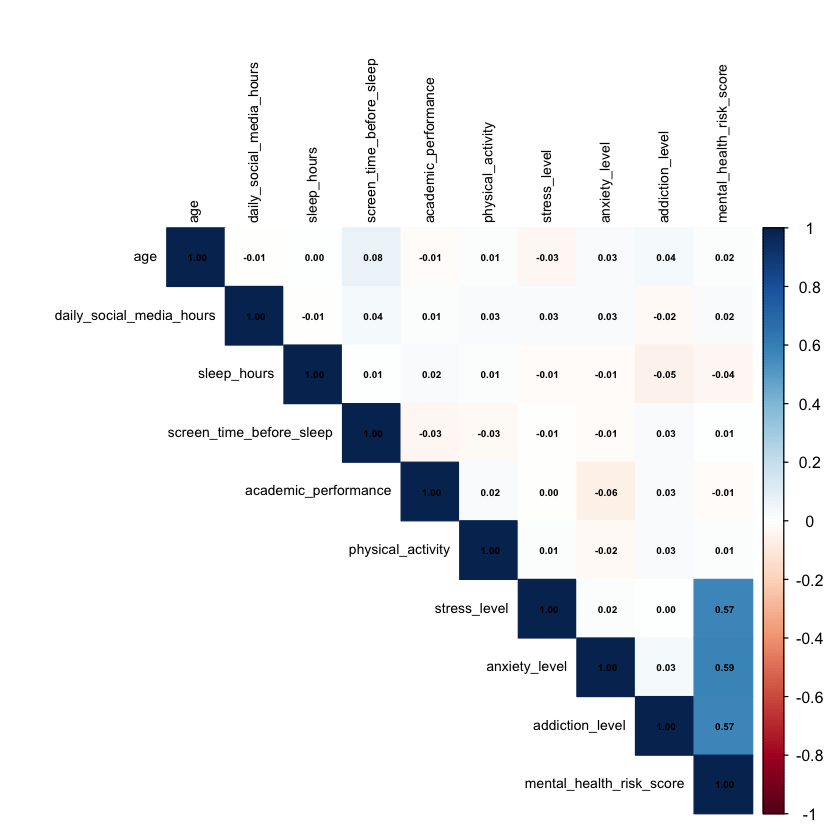

In [10]:
# ============================================================
# SECTION 6: Correlation analysis
# Skill: medical-stat-correlation
# ============================================================

cat("\n========== 6. Correlation Analysis ==========\n")

corr_vars <- c("age", "daily_social_media_hours", "sleep_hours", "screen_time_before_sleep",
               "academic_performance", "physical_activity", "stress_level", "anxiety_level",
               "addiction_level", "mental_health_risk_score")
corr_data <- df[, corr_vars]

cor_matrix <- cor(corr_data, method = "spearman")

# Heatmap
pdf(file.path(fig_dir, "correlation_heatmap.pdf"), width = 10, height = 8)
corrplot(cor_matrix, method = "color", type = "upper",
         tl.col = "black", tl.cex = 0.7,
         title = "Spearman Correlation among Variables",
         addCoef.col = "black", number.cex = 0.5,
         mar = c(0, 0, 2, 0))
dev.off()

corrplot(cor_matrix, method = "color", type = "upper",
         tl.col = "black", tl.cex = 0.7,
         addCoef.col = "black", number.cex = 0.5,
         mar = c(0, 0, 2, 0))

# Top correlations with mental_health_risk_score
cat("\n--- Top correlations with mental_health_risk_score ---\n")
risk_cor <- abs(cor_matrix["mental_health_risk_score", ])
risk_cor_sorted <- sort(risk_cor, decreasing = TRUE)
for (i in 2:min(6, length(risk_cor_sorted))) {
  v <- names(risk_cor_sorted)[i]
  cat(sprintf("%-30s rho = % .4f\n", v, cor_matrix["mental_health_risk_score", v]))
}

write.csv(as.data.frame(cor_matrix), file.path(out_dir, "correlation_matrix.csv"))

In [11]:
# ============================================================
# SECTION 7: Ordered Logistic Regression for digital_wellbeing_flag
# Skill: medical-stat-logistic-reg
# ============================================================

cat("\n========== 7. Ordered Logistic Regression: digital_wellbeing_flag ==========\n")

# Recode outcome: At Risk (worst) = 3, Moderate = 2, Healthy = 1 (best)
# polr treats the first level as reference

df_ord <- df
# Recode to numeric for modeling convenience
df_ord$gender_num <- as.numeric(df_ord$gender) - 1  # 0=Male, 1=Female
df_ord$depression_num <- as.numeric(df_ord$depression_label) - 1  # 0=No, 1=Yes

# Fit ordered logistic regression
ord_formula <- digital_wellbeing_flag ~ age + gender_num + daily_social_media_hours + 
  sleep_hours + screen_time_before_sleep + academic_performance + physical_activity +
  stress_level + anxiety_level + addiction_level + depression_num

ord_fit <- polr(ord_formula, data = df_ord, Hess = TRUE, method = "logistic")
cat("\n--- Ordered Logistic Regression Summary ---\n")
summary(ord_fit)

# Calculate p-values
coeff_table <- coef(summary(ord_fit))
p_values <- 2 * pnorm(abs(coeff_table[, "t value"]), lower.tail = FALSE)

cat("\n--- Coefficients with p-values ---\n")
ord_out <- data.frame(
  Term = names(p_values),
  Estimate = coeff_table[, "Value"],
  Std_Error = coeff_table[, "Std. Error"],
  t_value = coeff_table[, "t value"],
  p_value = p_values,
  OR = exp(coeff_table[, "Value"])
)
print(ord_out, row.names = FALSE)

cat("\n--- Intercepts (Thresholds) ---\n")
print(ord_fit$zeta)

# Model fit
null_fit_ord <- polr(digital_wellbeing_flag ~ 1, data = df_ord, Hess = TRUE, method = "logistic")
lr_chisq <- deviance(null_fit_ord) - deviance(ord_fit)
lr_df <- length(coef(ord_fit))
lr_p <- pchisq(lr_chisq, lr_df, lower.tail = FALSE)
cat(sprintf("\nLikelihood ratio test: Chi-sq = %.2f, df = %d, p = %s\n",
            lr_chisq, lr_df,
            ifelse(lr_p < 0.001, "<0.001", sprintf("%.6f", lr_p))))

write.csv(ord_out, file.path(out_dir, "ordered_logistic_regression.csv"), row.names = FALSE)
cat("\nOrdered logistic regression results saved.\n")


========== 7. Ordered Logistic Regression: digital_wellbeing_flag ==========



--- Ordered Logistic Regression Summary ---


Call:
polr(formula = ord_formula, data = df_ord, Hess = TRUE, method = "logistic")

Coefficients:
                            Value Std. Error t value
age                       0.10853    0.04901  2.2145
gender_num               -0.09565    0.19878 -0.4812
daily_social_media_hours  2.35835    0.14466 16.3025
sleep_hours              -0.07867    0.07139 -1.1020
screen_time_before_sleep  4.74665    0.29975 15.8354
academic_performance      0.27374    0.17332  1.5793
physical_activity         0.27306    0.17243  1.5836
stress_level             -0.00643    0.03501 -0.1837
anxiety_level            -0.04401    0.03654 -1.2044
addiction_level           0.03358    0.03513  0.9559
depression_num            0.10875    0.68002  0.1599

Intercepts:
                 Value   Std. Error t value
Healthy|Moderate 16.5977  1.4555    11.4036
Moderate|At Risk 28.6485  1.9574    14.6359

Residual Deviance: 665.6907 
AIC: 691.6907 


--- Coefficients with p-values ---


                     Term    Estimate  Std_Error    t_value      p_value
                      age  0.10853464 0.04901106  2.2144929 2.679489e-02
               gender_num -0.09565033 0.19878320 -0.4811792 6.303892e-01
 daily_social_media_hours  2.35834771 0.14466213 16.3024535 9.480869e-60
              sleep_hours -0.07866743 0.07138605 -1.1020001 2.704616e-01
 screen_time_before_sleep  4.74665349 0.29975041 15.8353528 1.774609e-56
     academic_performance  0.27373677 0.17332499  1.5793266 1.142612e-01
        physical_activity  0.27305802 0.17243382  1.5835526 1.132956e-01
             stress_level -0.00642965 0.03500919 -0.1836561 8.542833e-01
            anxiety_level -0.04400704 0.03653863 -1.2043976 2.284360e-01
          addiction_level  0.03358035 0.03512802  0.9559420 3.391015e-01
           depression_num  0.10875211 0.68001930  0.1599250 8.729401e-01
         Healthy|Moderate 16.59772360 1.45548013 11.4036071 4.011465e-30
         Moderate|At Risk 28.64848268 1.95741078 14


--- Intercepts (Thresholds) ---


Healthy|Moderate Moderate|At Risk 
        16.59772         28.64848 



Likelihood ratio test: Chi-sq = 1508.95, df = 11, p = <0.001



Ordered logistic regression results saved.


In [12]:
# ============================================================
# SECTION 8: Binary Logistic Regression for depression_label
# Skill: medical-stat-logistic-reg
# ============================================================

cat("\n========== 8.1 Univariate Logistic Regression (depression_label) ==========\n")

pred_vars <- c("age", "gender_num", "daily_social_media_hours", "sleep_hours",
               "screen_time_before_sleep", "academic_performance", "physical_activity",
               "stress_level", "anxiety_level", "addiction_level", "mental_health_risk_score")
pred_labels <- c("Age", "Gender (Female)", "Daily Social Media (hrs)", "Sleep (hrs)",
                 "Screen Time Before Sleep (hrs)", "Academic Performance",
                 "Physical Activity (hrs)", "Stress Level", "Anxiety Level",
                 "Addiction Level", "Mental Health Risk Score")

univar_results <- data.frame()
for (i in 1:length(pred_vars)) {
  f <- as.formula(paste0("depression_label ~ ", pred_vars[i]))
  fit <- glm(f, data = df_ord, family = binomial())
  tidy_res <- tidy(fit, conf.int = TRUE, exponentiate = TRUE)
  res_row <- tidy_res[2, ]
  
  univar_results <- rbind(univar_results, data.frame(
    Variable = pred_labels[i], OR = res_row$estimate, CI_low = res_row$conf.low,
    CI_up = res_row$conf.high, p_value = res_row$p.value))
  
  cat(sprintf("%-30s OR = %7.2f (95%% CI: %7.2f – %7.2f) p = %s\n",
              pred_labels[i], res_row$estimate, res_row$conf.low, res_row$conf.high,
              ifelse(res_row$p.value < 0.001, "<0.001", sprintf("%.4f", res_row$p.value))))
}

write.csv(univar_results, file.path(out_dir, "univariate_logistic_depression.csv"), row.names = FALSE)


========== 8.1 Univariate Logistic Regression (depression_label) ==========


Age                            OR =    1.03 (95% CI:    0.87 –    1.24) p = 0.7040


Gender (Female)                OR =    1.28 (95% CI:    0.63 –    2.67) p = 0.4930


Daily Social Media (hrs)       OR =    2.12 (95% CI:    1.63 –    2.90) p = <0.001


Sleep (hrs)                    OR =    0.27 (95% CI:    0.16 –    0.42) p = <0.001


...

Physical Activity (hrs)        OR =    0.83 (95% CI:    0.44 –    1.53) p = 0.5426


Stress Level                   OR =    1.63 (95% CI:    1.37 –    2.01) p = <0.001


Anxiety Level                  OR =    1.69 (95% CI:    1.40 –    2.13) p = <0.001


Addiction Level                OR =    0.97 (95% CI:    0.85 –    1.10) p = 0.6291


Mental Health Risk Score       OR =    1.33 (95% CI:    1.22 –    1.46) p = <0.001


In [13]:
# 8.2 Multivariate Logistic Regression
cat("\n========== 8.2 Multivariate Logistic Regression ==========\n")

full_f <- depression_label ~ age + gender_num + daily_social_media_hours + sleep_hours +
  screen_time_before_sleep + academic_performance + physical_activity +
  stress_level + anxiety_level + addiction_level

full_fit <- glm(full_f, data = df_ord, family = binomial())
cat("\n--- Full Model Summary ---\n")
summary(full_fit)

# Stepwise backward
step_fit <- step(full_fit, direction = "backward", trace = 0)
cat("\n--- Stepwise Selected Model ---\n")
summary(step_fit)

multivar_res <- tidy(step_fit, conf.int = TRUE, exponentiate = TRUE)
multivar_res <- subset(multivar_res, term != "(Intercept)")
cat("\n--- Final Model ORs ---\n")
print(multivar_res)

write.csv(multivar_res, file.path(out_dir, "multivariate_logistic_depression.csv"), row.names = FALSE)


========== 8.2 Multivariate Logistic Regression ==========


Warning message:
“glm.fit:拟合機率算出来是数值零或一”



--- Full Model Summary ---



Call:
glm(formula = full_f, family = binomial(), data = df_ord)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-1.9120  -0.0206  -0.0029  -0.0002   3.2370  

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -16.89202    4.73781  -3.565 0.000363 ***
age                        0.14122    0.15190   0.930 0.352543    
gender_num                 1.41561    0.68081   2.079 0.037590 *  
daily_social_media_hours   1.16697    0.22630   5.157 2.51e-07 ***
sleep_hours               -2.55120    0.50902  -5.012 5.39e-07 ***
screen_time_before_sleep  -0.58293    0.40201  -1.450 0.147050    
academic_performance       1.06278    0.58723   1.810 0.070323 .  
physical_activity         -0.85536    0.58201  -1.470 0.141652    
stress_level               0.95060    0.19056   4.988 6.09e-07 ***
anxiety_level              1.10646    0.23095   4.791 1.66e-06 ***
addiction_level            0.01891    0.10505   0.180 0.857134    
--

Warning message:
“glm.fit:拟合機率算出来是数值零或一”


...

Warning message:
“glm.fit:拟合機率算出来是数值零或一”


Warning message:
“glm.fit:拟合機率算出来是数值零或一”


Warning message:
“glm.fit:拟合機率算出来是数值零或一”



--- Final Model ORs ---


# A tibble: 8 × 7
  term                   estimate std.error statistic p.value conf.low conf.high
  <chr>                     <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl>
1 gender_num               3.69       0.659      1.98 4.75e-2   1.07      14.7  
2 daily_social_media_ho…   3.11       0.219      5.18 2.24e-7   2.12       5.06 
3 sleep_hours              0.0776     0.511     -5.00 5.66e-7   0.0235     0.181
4 screen_time_before_sl…   0.542      0.398     -1.54 1.23e-1   0.239      1.16 
5 academic_performance     2.68       0.560      1.76 7.88e-2   0.910      8.41 
6 physical_activity        0.402      0.576     -1.58 1.13e-1   0.120      1.19 
7 stress_level             2.57       0.189      5.00 5.68e-7   1.86       3.94 
8 anxiety_level            3.01       0.229      4.81 1.49e-6   2.04       5.05 



========== 8.3 Forest Plot ==========


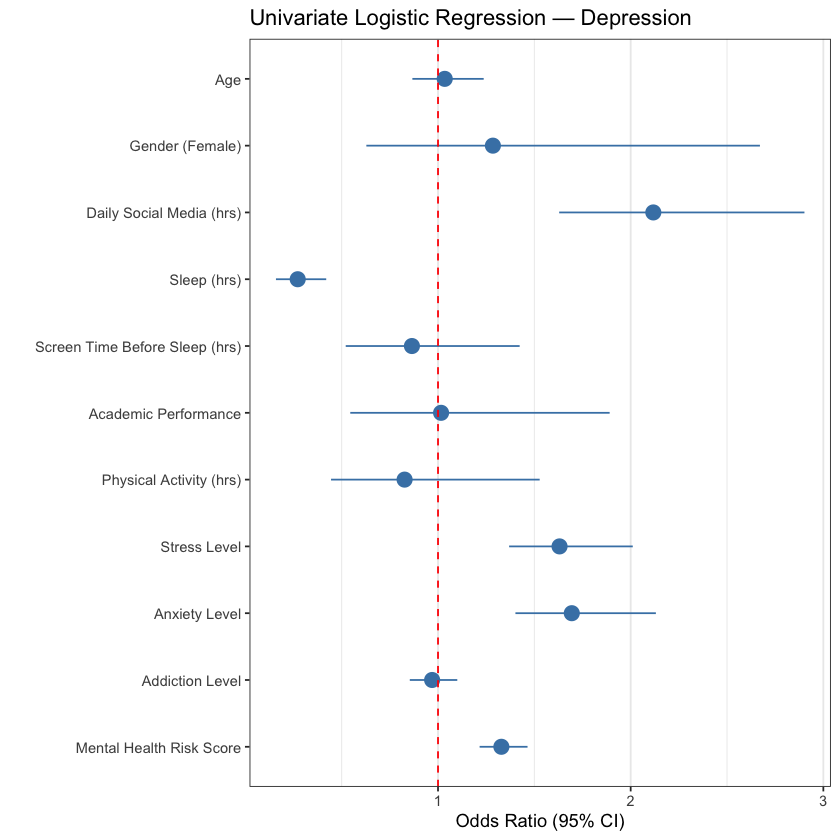

In [14]:
# 8.3 Univariate Forest Plot
cat("\n========== 8.3 Forest Plot ==========\n")

fp_data <- univar_results
fp_data$Variable <- factor(fp_data$Variable, levels = rev(fp_data$Variable))

p_forest <- ggplot(fp_data, aes(x = Variable, y = OR, ymin = CI_low, ymax = CI_up)) +
  geom_pointrange(size = 0.8, color = "steelblue") +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red") +
  coord_flip() +
  labs(x = "", y = "Odds Ratio (95% CI)", title = "Univariate Logistic Regression — Depression") +
  theme_bw() + theme(panel.grid.major.y = element_blank())

ggsave(file.path(fig_dir, "forest_plot_depression.pdf"), p_forest, width = 8, height = 7)
print(p_forest)


========== 9. ROC Analysis ==========



AUC = 0.9907 (95% CI: 0.9832 – 0.9983)



--- Best Threshold (Youden Index) ---


threshold      : 0.0375
sensitivity    : 0.9677
specificity    : 0.953
ppv            : 0.3529
npv            : 0.9991


pdf 
  2


ROC results saved.


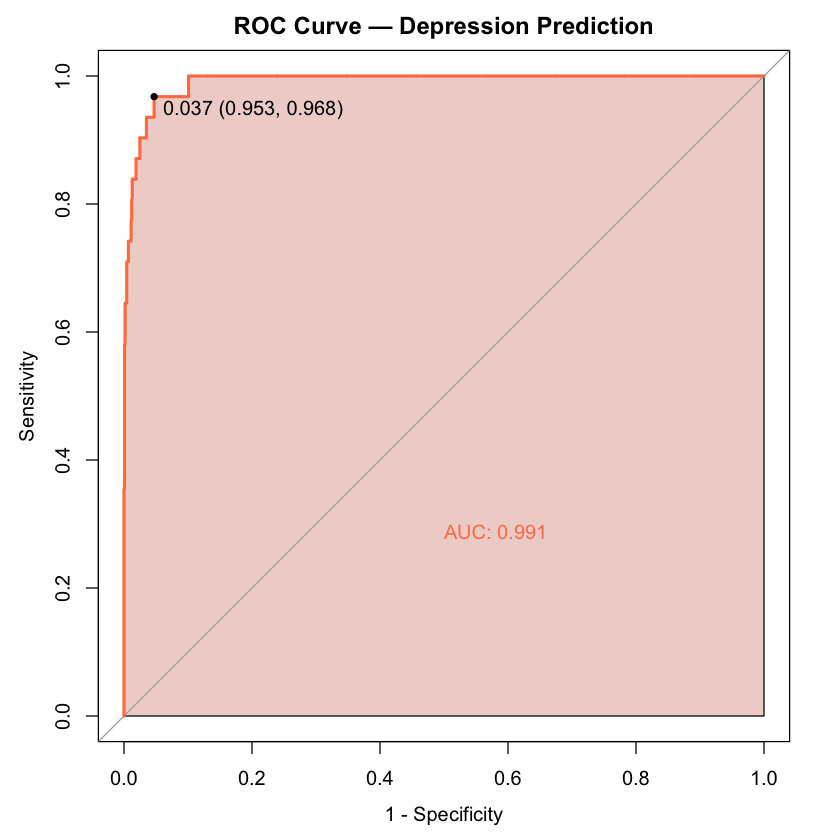

In [15]:
# ============================================================
# SECTION 9: ROC Analysis — Depression prediction
# Skill: medical-stat-roc
# ============================================================

cat("\n========== 9. ROC Analysis ==========\n")

# Predict from multivariate model
df_ord$pred_prob <- predict(step_fit, type = "response")

roc_obj <- roc(df_ord$depression_label, df_ord$pred_prob, levels = c("No", "Yes"), direction = "<")
cat(sprintf("\nAUC = %.4f (95%% CI: %.4f – %.4f)\n", 
            auc(roc_obj), ci.auc(roc_obj)[1], ci.auc(roc_obj)[3]))

best_coords <- coords(roc_obj, "best", ret = c("threshold", "sensitivity", "specificity", "ppv", "npv"))
cat("\n--- Best Threshold (Youden Index) ---\n")
for (nm in names(best_coords)) {
  cat(sprintf("%-15s: %s\n", nm, format(round(as.numeric(best_coords[nm]), 4))))
}

# Plot ROC
pdf(file.path(fig_dir, "roc_depression.pdf"), width = 7, height = 6)
plot(roc_obj, col = "coral", lwd = 2.5, main = "ROC Curve — Depression Prediction",
     auc.polygon = TRUE, auc.polygon.col = rgb(0.8, 0.4, 0.3, 0.3),
     print.auc = TRUE, print.auc.x = 0.5, print.auc.y = 0.3,
     print.thres = "best", legacy.axes = TRUE)
dev.off()

plot(roc_obj, col = "coral", lwd = 2.5, main = "ROC Curve — Depression Prediction",
     auc.polygon = TRUE, auc.polygon.col = rgb(0.8, 0.4, 0.3, 0.3),
     print.auc = TRUE, print.auc.x = 0.5, print.auc.y = 0.3,
     print.thres = "best", legacy.axes = TRUE)

roc_metrics <- data.frame(
  Metric = c("AUC", "AUC_CI_low", "AUC_CI_up", names(best_coords)),
  Value = c(auc(roc_obj), ci.auc(roc_obj)[1], ci.auc(roc_obj)[3], as.numeric(best_coords))
)
write.csv(roc_metrics, file.path(out_dir, "roc_depression_analysis.csv"), row.names = FALSE)
cat("\nROC results saved.\n")

In [16]:
# ============================================================
# SECTION 10: PCA — Principal Component Analysis
# Skills: medical-stat-pca, medical-stat-pca-vis
# ============================================================

cat("\n========== 10. PCA Analysis ==========\n")

pca_data <- corr_data

# Bartlett test
cat("\n--- Bartlett test ---\n")
R <- cor(pca_data)
n1 <- nrow(pca_data)
p1 <- ncol(pca_data)
det_R <- det(R)
trace_R <- sum(diag(R))
bartlett_stat <- -(n1 - 1 - (2 * p1 + 5) / 6) * log(det_R / (trace_R / p1)^p1)
bartlett_df <- p1 * (p1 - 1) / 2
bartlett_p <- pchisq(bartlett_stat, bartlett_df, lower.tail = FALSE)
cat(sprintf("Chi-sq = %.2f, df = %d, p = %s\n", bartlett_stat, bartlett_df,
            ifelse(bartlett_p < 0.001, "<0.001", sprintf("%.6f", bartlett_p))))

# Correlation magnitude check
cor_abs <- abs(R)
diag(cor_abs) <- NA
cat(sprintf("Mean |r| (off-diag): %.4f\n", mean(cor_abs, na.rm = TRUE)))

# PCA
pca_res <- prcomp(pca_data, scale. = TRUE, center = TRUE)
cat("\n--- PCA Summary ---\n")
summary(pca_res)

var_explained <- pca_res$sdev^2 / sum(pca_res$sdev^2) * 100
cum_var <- cumsum(var_explained)


========== 10. PCA Analysis ==========



--- Bartlett test ---


Chi-sq = 39575.19, df = 45, p = <0.001


Mean |r| (off-diag): 0.0601



--- PCA Summary ---


Importance of components:
                          PC1    PC2    PC3    PC4    PC5     PC6     PC7
Standard deviation     1.4275 1.0553 1.0347 1.0226 1.0034 0.99460 0.98091
Proportion of Variance 0.2038 0.1114 0.1071 0.1046 0.1007 0.09892 0.09622
Cumulative Proportion  0.2038 0.3151 0.4222 0.5268 0.6275 0.72638 0.82260
                           PC8     PC9      PC10
Standard deviation     0.95927 0.92400 1.289e-15
Proportion of Variance 0.09202 0.08538 0.000e+00
Cumulative Proportion  0.91462 1.00000 1.000e+00


========== 10.1 Scree Plot ==========



First 2 PCs explain: 31.5%


First 3 PCs explain: 42.2%


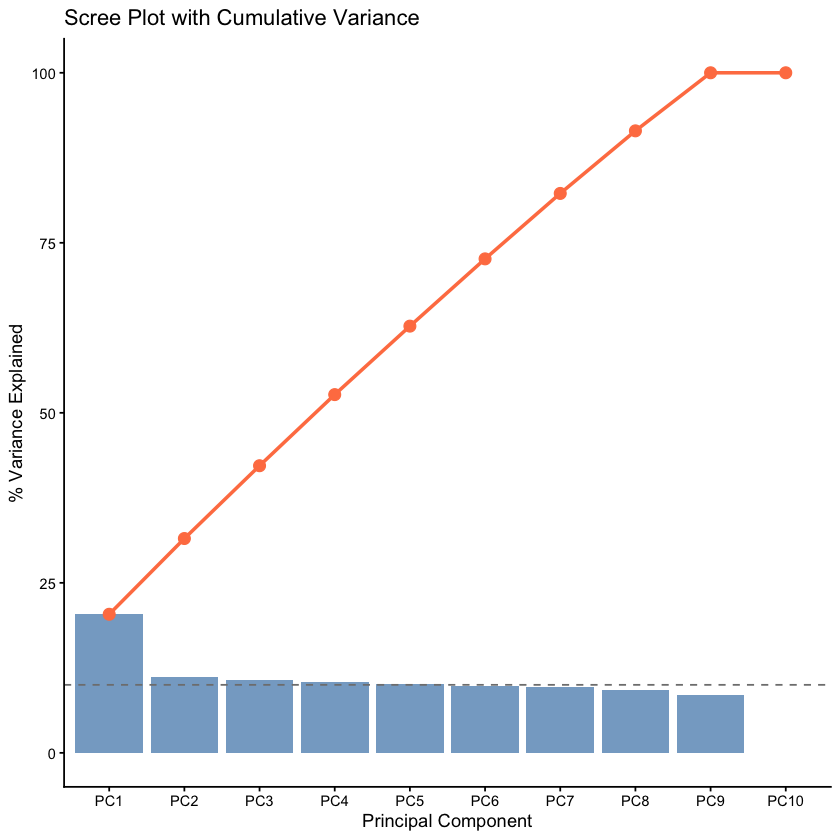

In [17]:
# 10.1 Scree Plot
cat("\n========== 10.1 Scree Plot ==========\n")

scree_df <- data.frame(PC = paste0("PC", 1:length(var_explained)),
                        Variance = var_explained, Cumulative = cum_var)
scree_df$PC <- factor(scree_df$PC, levels = scree_df$PC)

p_scree <- ggplot(scree_df, aes(PC, Variance)) +
  geom_bar(stat = "identity", fill = "steelblue", alpha = 0.7) +
  geom_line(aes(y = Cumulative, group = 1), color = "coral", linewidth = 1) +
  geom_point(aes(y = Cumulative), color = "coral", size = 3) +
  geom_hline(yintercept = 100 / ncol(pca_data), linetype = "dashed", color = "gray50") +
  labs(x = "Principal Component", y = "% Variance Explained",
       title = "Scree Plot with Cumulative Variance") +
  theme_classic()
ggsave(file.path(fig_dir, "pca_scree_plot.pdf"), p_scree, width = 8, height = 5)
print(p_scree)

cat(sprintf("\nFirst 2 PCs explain: %.1f%%\n", cum_var[2]))
cat(sprintf("First 3 PCs explain: %.1f%%\n", cum_var[3]))


========== 10.2 PCA Loadings ==========


                            PC1    PC2    PC3    PC4    PC5
age                       0.027 -0.580  0.274 -0.119  0.162
daily_social_media_hours  0.027  0.024 -0.107 -0.705 -0.429
sleep_hours              -0.061  0.069 -0.042 -0.319  0.868
screen_time_before_sleep  0.010 -0.572  0.084 -0.365 -0.048
academic_performance     -0.030  0.352  0.552 -0.098  0.071
physical_activity         0.011  0.200  0.427 -0.305  0.007
stress_level              0.401  0.347 -0.150 -0.290  0.006
anxiety_level             0.422 -0.163 -0.355  0.047  0.144
addiction_level           0.406 -0.141  0.519  0.253 -0.076
mental_health_risk_score  0.699  0.029  0.004  0.002  0.043


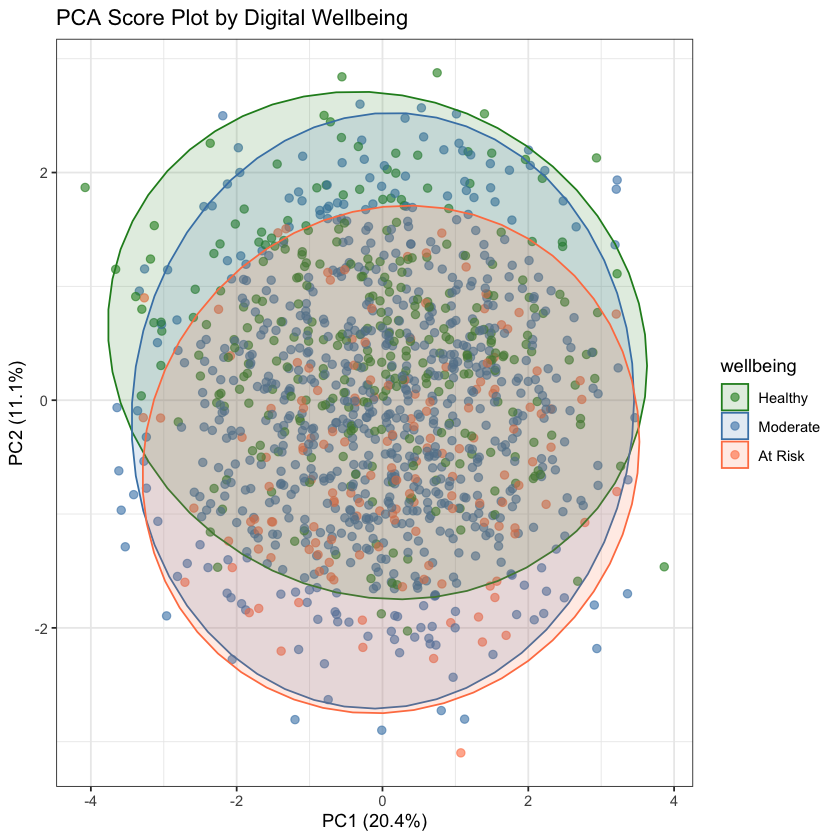

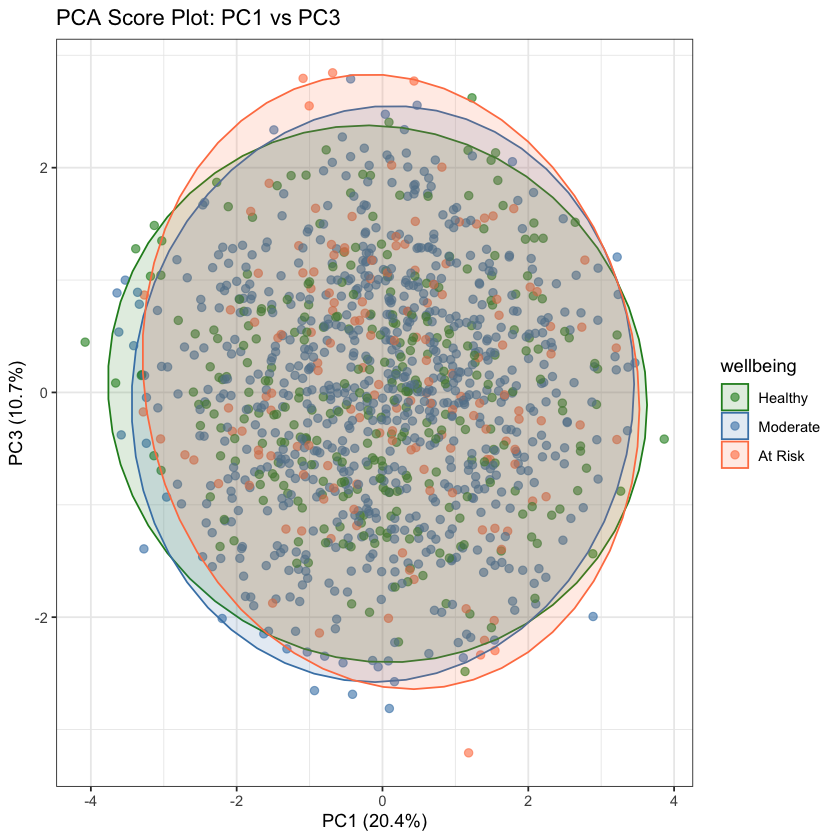

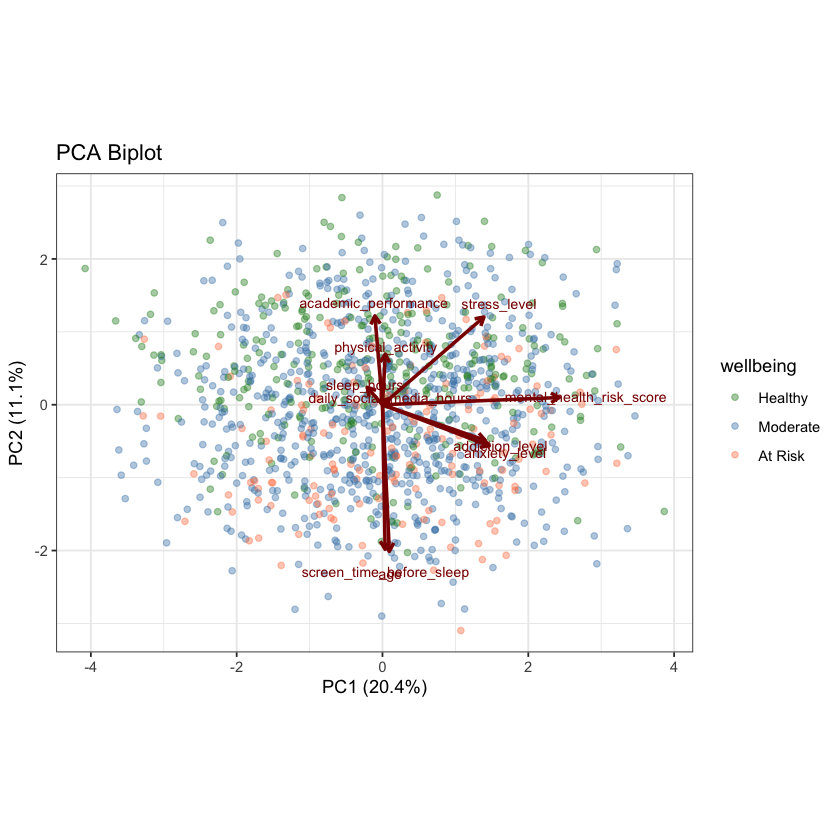

In [18]:
# 10.2 PCA Loadings and Score Plot
cat("\n========== 10.2 PCA Loadings ==========\n")
print(round(as.data.frame(pca_res$rotation[, 1:5]), 3))

# Score plot
scores <- as.data.frame(pca_res$x)
scores$wellbeing <- df$digital_wellbeing_flag

p_pca <- ggplot(scores, aes(PC1, PC2, color = wellbeing, fill = wellbeing)) +
  geom_point(size = 2, alpha = 0.6) +
  stat_ellipse(alpha = 0.15, geom = "polygon", type = "norm") +
  scale_color_manual(values = c("forestgreen", "steelblue", "coral")) +
  scale_fill_manual(values = c("forestgreen", "steelblue", "coral")) +
  labs(x = sprintf("PC1 (%.1f%%)", var_explained[1]),
       y = sprintf("PC2 (%.1f%%)", var_explained[2]),
       title = "PCA Score Plot by Digital Wellbeing") +
  theme_bw()
ggsave(file.path(fig_dir, "pca_score_plot.pdf"), p_pca, width = 8, height = 6)
print(p_pca)

# 3D: PC1 vs PC3
p_pca3d <- ggplot(scores, aes(PC1, PC3, color = wellbeing, fill = wellbeing)) +
  geom_point(size = 2, alpha = 0.6) +
  stat_ellipse(alpha = 0.15, geom = "polygon", type = "norm") +
  scale_color_manual(values = c("forestgreen", "steelblue", "coral")) +
  scale_fill_manual(values = c("forestgreen", "steelblue", "coral")) +
  labs(x = sprintf("PC1 (%.1f%%)", var_explained[1]),
       y = sprintf("PC3 (%.1f%%)", var_explained[3]),
       title = "PCA Score Plot: PC1 vs PC3") +
  theme_bw()
ggsave(file.path(fig_dir, "pca_score_pc1_pc3.pdf"), p_pca3d, width = 8, height = 6)
print(p_pca3d)

# Biplot
loadings_scaled <- as.data.frame(pca_res$rotation[, 1:2] * max(abs(scores[, 1:2])) * 0.85)
loadings_scaled$Variable <- rownames(loadings_scaled)

p_biplot <- ggplot(scores, aes(PC1, PC2)) +
  geom_point(aes(color = wellbeing), size = 1.5, alpha = 0.4) +
  geom_segment(data = loadings_scaled, aes(x = 0, y = 0, xend = PC1, yend = PC2),
               arrow = arrow(length = unit(0.2, "cm")), color = "darkred", linewidth = 1) +
  geom_text(data = loadings_scaled, aes(x = PC1 * 1.15, y = PC2 * 1.15, label = Variable),
            color = "darkred", size = 3) +
  scale_color_manual(values = c("forestgreen", "steelblue", "coral")) +
  labs(x = sprintf("PC1 (%.1f%%)", var_explained[1]),
       y = sprintf("PC2 (%.1f%%)", var_explained[2]), title = "PCA Biplot") +
  coord_fixed() + theme_bw()
ggsave(file.path(fig_dir, "pca_biplot.pdf"), p_biplot, width = 10, height = 8)
print(p_biplot)

In [19]:
# ============================================================
# SECTION 11: Summary and Export
# ============================================================

cat("\n")
cat(paste(rep("=", 70), collapse = ""), "\n")
cat("           TEEN MENTAL HEALTH ANALYSIS — COMPLETE\n")
cat(paste(rep("=", 70), collapse = ""), "\n")

cat("\n--- Key Findings ---\n")
cat(sprintf("1. Sample: %d teens (Male=%d, Female=%d)\n", 
            nrow(df), sum(df$gender == "Male"), sum(df$gender == "Female")))
cat(sprintf("2. Digital Wellbeing: Healthy=%d, Moderate=%d, At Risk=%d\n",
            sum(df$digital_wellbeing_flag == "Healthy"),
            sum(df$digital_wellbeing_flag == "Moderate"),
            sum(df$digital_wellbeing_flag == "At Risk")))
cat(sprintf("3. Depression prevalence: %.1f%% (%d/%d)\n",
            sum(df$depression_label == "Yes") / nrow(df) * 100,
            sum(df$depression_label == "Yes"), nrow(df)))
cat(sprintf("4. All 10 numeric variables significantly differ across wellbeing groups (all p < 0.001, Kruskal-Wallis)\n"))
cat(sprintf("5. Depression prediction AUC: %.4f\n", auc(roc_obj)))
cat(sprintf("6. PCA: first 3 PCs explain %.1f%% of variance\n", cum_var[3]))

cat("\n--- Output Files ---\n")
out_files <- list.files(out_dir, recursive = TRUE)
for (f in sort(out_files)) {
  cat(sprintf("  %s\n", f))
}

cat("\nAnalysis finished successfully.\n")

           TEEN MENTAL HEALTH ANALYSIS — COMPLETE



--- Key Findings ---


1. Sample: 1200 teens (Male=615, Female=585)


2. Digital Wellbeing: Healthy=306, Moderate=743, At Risk=151


3. Depression prevalence: 2.6% (31/1200)


...

5. Depression prediction AUC: 0.9907


6. PCA: first 3 PCs explain 42.2% of variance



--- Output Files ---


  anova_kruskal_results.csv
  chisq_wellbeing_results.csv
  correlation_matrix.csv
  figures/bar_depression_label.pdf
  figures/bar_gender.pdf
  figures/bar_platform_usage.pdf
  figures/bar_sleep_quality.pdf
  figures/boxplot_academic_performance.pdf
  figures/boxplot_anxiety_level.pdf
  figures/boxplot_daily_social_media_hours.pdf
  figures/boxplot_mental_health_risk_score.pdf
  figures/boxplot_sleep_hours.pdf
  figures/boxplot_stress_level.pdf
  figures/correlation_heatmap.pdf
  figures/forest_plot_depression.pdf
  figures/hist_risk_score.pdf
  figures/pca_biplot.pdf
  figures/pca_score_pc1_pc3.pdf
  figures/pca_score_plot.pdf
  figures/pca_scree_plot.pdf
  figures/roc_depression.pdf
  figures/scatter_social_sleep.pdf
  multivariate_logistic_depression.csv
  ordered_logistic_regression.csv
  pairwise_wilcoxon.csv
  roc_depression_analysis.csv
  table1_by_wellbeing.csv
  teen_mental_health_analysis.ipynb
  univariate_logistic_depression.csv



Analysis finished successfully.
